In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Оценка стоимости кварталов

In [35]:
blocks_gdf = gdf = pd.read_pickle("../data/traning_data/blocks.pickle")
blocks_gdf.columns

Index(['geometry', 'residential', 'business', 'recreation', 'industrial',
       'transport', 'special', 'agriculture', 'land_use', 'share',
       ...
       'capacity_prison', 'count_prison', 'capacity_landfill',
       'count_landfill', 'capacity_plant_nursery', 'count_plant_nursery',
       'capacity_greenhouse_complex', 'count_greenhouse_complex',
       'capacity_warehouse', 'count_warehouse'],
      dtype='object', length=136)

In [3]:
cadastr_blocks = gpd.read_parquet('../data/traning_data/spb_bloks_price.parquet')
cadastr_blocks.head()

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry
0,78,"Санкт-Петербург, город Зеленогорск, Решетников...",10833260.98,5846.3362,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,1852.0,"POLYGON ((3306132.351 8453357.197, 3306131.265..."
1,78,"г.Санкт-Петербург, город Зеленогорск, Решетник...",6533139.72,5444.2831,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,1200.0,"POLYGON ((3306613.198 8453876.707, 3306609.831..."
2,78,"Санкт-Петербург, город Зеленогорск, Красавица,...",16395.97,1366.3305,Земли населенных пунктов,Для размещения объектов коммунального хозяйства,12.0,"POLYGON ((3311932.709 8453466.264, 3311927.608..."
3,78,"Санкт-Петербург, город Зеленогорск, Решетников...",8425371.37,5513.9865,Земли населенных пунктов,Для размещения индивидуального (одноквартирног...,1528.0,"POLYGON ((3306341.721 8454345.055, 3306347.49 ..."
4,78,"Санкт-Петербург, город Зеленогорск, Решетников...",11430710.60,5715.3553,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,2000.0,"POLYGON ((3306583.407 8453412.704, 3306580.412..."


In [8]:
# Список всех категорий и количество значений в каждой (включая NaN)
col = "permitted_use_established_by_document"

counts = (
    cadastr_blocks[col]
    .value_counts(dropna=False)
    .rename_axis(col)
    .reset_index(name="count")
)
print(counts.to_string(index=False, justify="right"))



In [37]:
cadastr_blocks['log_cost_index'] = np.log1p(cadastr_blocks['cost_index'])

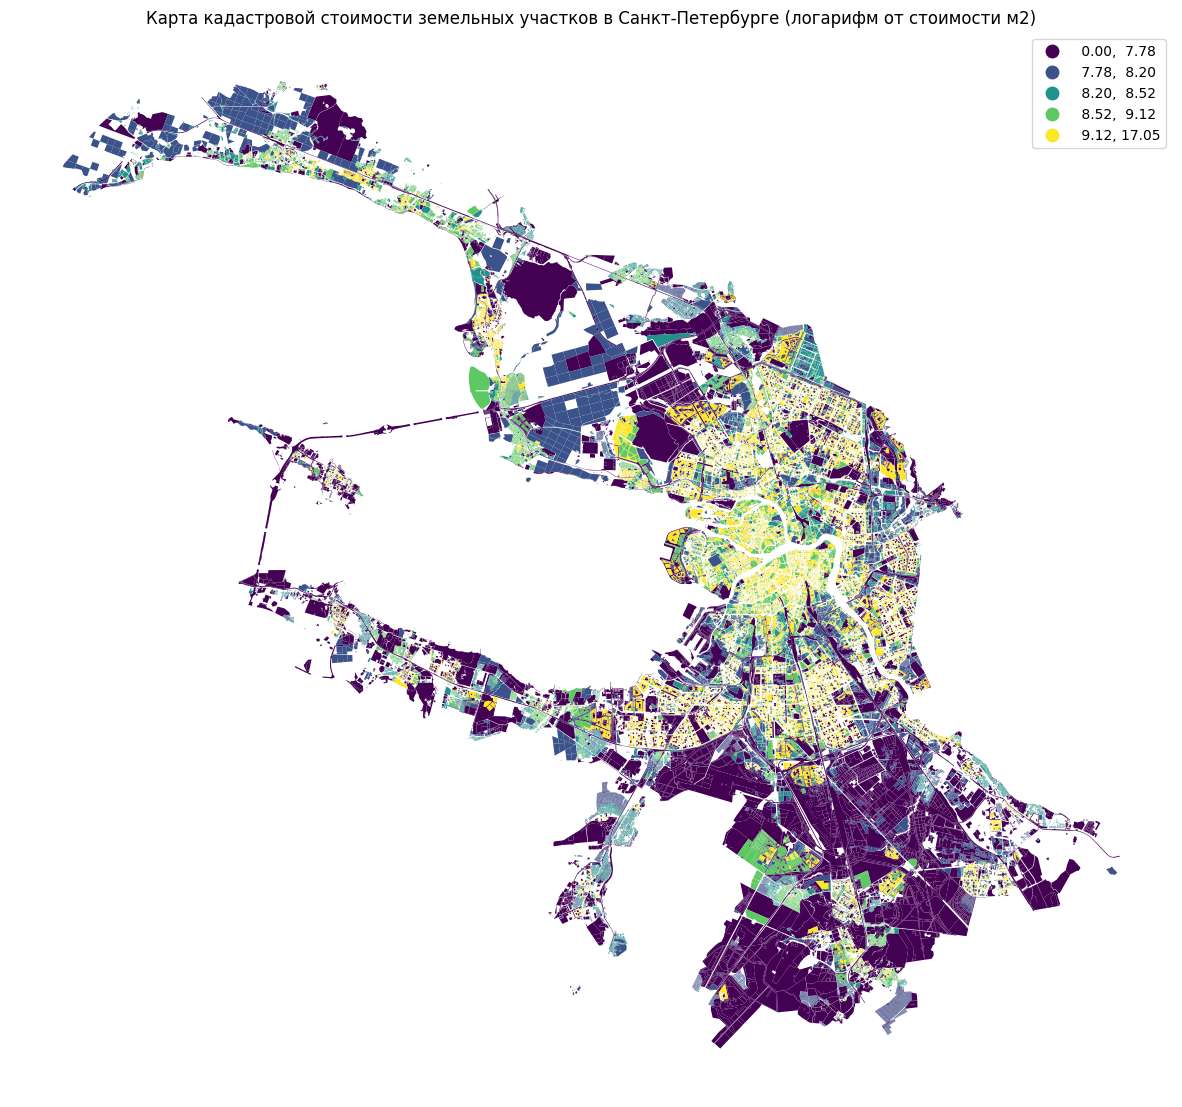

In [38]:
# Картируем лог-цену
cadastr_blocks.plot(
    column='log_cost_index',
    scheme='quantiles',
    legend=True,
    figsize=(15,15),
    cmap='viridis'
).set_axis_off()
plt.title('Карта кадастровой стоимости земельных участков в Санкт-Петербурге (логарифм от стоимости м2)')

plt.show()

In [40]:
cadastr_blocks

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry,log_cost_index
0,78,"Санкт-Петербург, город Зеленогорск, Решетников...","10,833,260.98","5,846.34",Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,"1,852.00","POLYGON ((3306132.351 8453357.197, 3306131.265...",8.67
1,78,"г.Санкт-Петербург, город Зеленогорск, Решетник...","6,533,139.72","5,444.28",Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,"1,200.00","POLYGON ((3306613.198 8453876.707, 3306609.831...",8.60
2,78,"Санкт-Петербург, город Зеленогорск, Красавица,...","16,395.97","1,366.33",Земли населенных пунктов,Для размещения объектов коммунального хозяйства,12.00,"POLYGON ((3311932.709 8453466.264, 3311927.608...",7.22
3,78,"Санкт-Петербург, город Зеленогорск, Решетников...","8,425,371.37","5,513.99",Земли населенных пунктов,Для размещения индивидуального (одноквартирног...,"1,528.00","POLYGON ((3306341.721 8454345.055, 3306347.49 ...",8.62
4,78,"Санкт-Петербург, город Зеленогорск, Решетников...","11,430,710.60","5,715.36",Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,"2,000.00","POLYGON ((3306583.407 8453412.704, 3306580.412...",8.65
...,...,...,...,...,...,...,...,...,...
136534,78,"Санкт-Петербург, город Павловск, садоводство ""...","2,177,378.29","3,114.99",Земли населенных пунктов,для садоводства,699.00,"POLYGON ((3391633.921 8321046.994, 3391661.476...",8.04
136535,78,"Санкт-Петербург, город Павловск, садоводство ""...","2,211,847.66","3,115.28",Земли населенных пунктов,для садоводства,710.00,"POLYGON ((3391509.927 8320811.034, 3391477.491...",8.04
136536,78,"Санкт-Петербург, город Павловск, садоводство ""...","2,227,101.45","3,114.83",Земли населенных пунктов,для садоводства,715.00,"POLYGON ((3391705.505 8321023.296, 3391744.956...",8.04
136537,78,"Санкт-Петербург, город Павловск, садоводство ""...","2,074,858.38","3,110.73",Земли населенных пунктов,для садоводства,667.00,"POLYGON ((3391524.786 8321125.747, 3391556.645...",8.04


In [41]:
import geopandas as gpd

# — 1. Клонируем оригиналы, чтобы не портить исходники
blocks = blocks_gdf.copy()
cad    = cadastr_blocks.copy()

# — 2. Приводим к единому CRS (он нужен для корректных площадей)
if blocks.crs != cad.crs:
    cad = cad.to_crs(blocks.crs)

# — 3. Считаем полную площадь cadastral-полигонов
cad['cad_area'] = cad.geometry.area

# — 4. Явно добавляем в blocks колонку block_id из индекса
blocks['block_id'] = blocks.index

# — 5. Пересечение кварталов и кадастра
inter = gpd.overlay(
    blocks[['block_id', 'geometry']],
    cad   [['cost_value', 'cad_area', 'geometry']],
    how='intersection'
)

# — 6. Площадь каждого куска пересечения
inter['int_area'] = inter.geometry.area

# — 7. Вклады стоимости пропорционально площади
inter['cost_contrib'] = inter['cost_value'] * inter['int_area'] / inter['cad_area']

# — 8. Суммируем для каждого квартала
block_costs = (
    inter
    .groupby('block_id', as_index=False)['cost_contrib']
    .sum()
    .rename(columns={'cost_contrib':'land_value'})
)

# — 9. Мерджим обратно в blocks, заполняем пропуски нулями
blocks = blocks.merge(block_costs, on='block_id', how='left')
blocks['land_value'] = blocks['land_value'].fillna(0)

# — 10. При желании убираем служебный block_id (или возвращаем исходный индекс)
blocks = blocks.drop(columns=['block_id'])
blocks


/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_2765/1539363365.py:18: UserWarning: `keep_geom_type=True` in overlay resulted in 64 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  inter = gpd.overlay(


,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,count_prison,capacity_landfill,count_landfill,capacity_plant_nursery,count_plant_nursery,capacity_greenhouse_complex,count_greenhouse_complex,capacity_warehouse,count_warehouse,land_value
0,"POLYGON ((349424.859 6631180.891, 349424.751 6...",0.00,0.00,0.00,0.00,1.00,0.00,0.00,LandUse.TRANSPORT,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.10,0.00,0.08,0.00,0.40,0.00,0.42,LandUse.AGRICULTURE,0.42,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"129,202,173.99"
2,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.00,0.00,0.00,0.00,0.00,0.00,0.00,LandUse.RESIDENTIAL,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"185,946,167.88"
3,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.73,0.00,0.27,0.00,0.00,0.00,0.00,LandUse.RESIDENTIAL,0.73,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"189,788,550.29"
4,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.45,0.00,0.00,0.00,0.14,0.00,0.40,LandUse.RESIDENTIAL,0.45,...,0.00,0.00,0.00,30.00,1.00,0.00,0.00,0.00,0.00,"373,309,691.92"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9363,"POLYGON ((346635.461 6647492.048, 346473.426 6...",0.94,0.00,0.00,0.00,0.06,0.00,0.00,LandUse.RESIDENTIAL,0.94,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"219,055,949.96"
9364,"POLYGON ((346361.221 6647603.446, 346328.072 6...",0.13,0.00,0.27,0.00,0.61,0.00,0.00,LandUse.TRANSPORT,0.61,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"374,720,759.23"
9365,"POLYGON ((344109.285 6649134.367, 344000.209 6...",0.00,0.00,0.76,0.00,0.23,0.00,0.00,LandUse.RECREATION,0.76,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"171,830,996.74"
9366,"POLYGON ((346323.488 6649497.386, 346199.573 6...",0.40,0.00,0.00,0.47,0.12,0.00,0.00,LandUse.INDUSTRIAL,0.47,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,150.00,1.00,"259,244,013.72"


In [8]:
# 1. Если CRS географический (deg), переведём в метрический (например, Меркатор)
if blocks.crs.is_geographic:
    blocks = blocks.to_crs(epsg=3857)

# 2. Считаем площадь каждого квартала в м²
blocks['site_area'] = blocks.geometry.area
blocks = blocks.to_crs(epsg=32636)



In [ ]:
out_df_over_10

In [8]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# blocks['log_std'] = scaler.fit_transform(
#     blocks[['log_price']]
# )

In [9]:
# from sklearn.cluster import KMeans

# # Берём только ненулевые и не NaN
# X = blocks[['log_price']].dropna()

# kmeans = KMeans(n_clusters=6, random_state=0)
# blocks.loc[X.index, 'cluster'] = kmeans.fit_predict(X)

# # Визуализируем
# blocks.plot(
#     column='cluster',
#     categorical=True,
#     legend=True,
#     figsize=(15,15)
# ).set_axis_off()
# plt.title('Кластеры кварталов по цене за квадратный метр')
# plt.show()


In [9]:
# Собираем все имена колонок, которые начинаются на 'capacity'
cols_to_drop = [col for col in blocks.columns if col.startswith('capacity')]
blocks = blocks.drop(columns=cols_to_drop)
cols_to_drop = [col for col in blocks.columns if col.startswith('count')]
# blocks = blocks.drop(columns='cluster')
# Удаляем их сразу все
blocks = blocks.drop(columns=cols_to_drop)

blocks.columns

Index(['geometry', 'residential', 'business', 'recreation', 'industrial',
       'transport', 'special', 'agriculture', 'land_use', 'share',
       'footprint_area', 'build_floor_area', 'living_area', 'non_living_area',
       'population', 'land_value', 'site_area'],
      dtype='object')

In [10]:
blocks['land_use'] = (
    blocks['land_use']
    .astype(str)
    .str.replace(r'^LandUse\.', '', regex=True)
)

## Дополнитльные метрики

In [11]:
from blocksnet.analysis.indicators import calculate_density_indicators 

blocks_df = calculate_density_indicators(blocks[[
    'site_area',
    'footprint_area', 
    'build_floor_area',
    'living_area',
    'non_living_area'
]])
blocks_df

,site_area,footprint_area,build_floor_area,living_area,non_living_area,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,0.032316,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,inf,NaN,NaN
1,137101.088247,69.018103,69.018103,0.000000,69.018103,0.000503,0.000503,0.000000,1.000000,1985.451134,0.000000,1.000000
2,95239.084434,5853.863274,6106.759644,4197.188633,1909.571011,0.064120,0.061465,0.687302,1.043202,14.637095,0.716995,0.326207
3,125919.330984,4214.828165,4375.483259,3033.795607,1341.687653,0.034748,0.033472,0.693362,1.038117,27.815100,0.719791,0.318326
4,169860.164494,13392.846325,31242.324144,20860.965881,10381.358263,0.183930,0.078846,0.667715,2.332762,5.008184,1.557620,0.775142
...,...,...,...,...,...,...,...,...,...,...,...,...
9363,16802.384600,4360.962708,21549.418762,9911.577637,11637.841125,1.282521,0.259544,0.459946,4.941436,0.577344,2.272796,2.668640
9364,47637.956433,14963.573074,73149.192154,0.000000,73149.192154,1.535523,0.314110,0.000000,4.888484,0.446681,0.000000,4.888484
9365,64487.699525,25.673922,25.673922,0.000000,25.673922,0.000398,0.000398,0.000000,1.000000,2510.797791,0.000000,1.000000
9366,42988.399080,12973.889317,52737.331333,0.000000,52737.331333,1.226781,0.301800,0.000000,4.064882,0.569132,0.000000,4.064882


In [12]:
blocks.loc[:, blocks_df.columns] = blocks_df
blocks

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,population,land_value,site_area,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,"POLYGON ((349424.859 6631180.891, 349424.751 6...",0.000000,0.0,0.000000,0.000000,1.000000,0.0,0.000000,TRANSPORT,1.000000,...,0.0,0.000000e+00,0.032316,0.000000,0.000000,NaN,NaN,inf,NaN,NaN
1,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,0.0,1.292022e+08,137101.088247,0.000503,0.000503,0.000000,1.000000,1985.451134,0.000000,1.000000
2,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,109.0,1.859462e+08,95239.084434,0.064120,0.061465,0.687302,1.043202,14.637095,0.716995,0.326207
3,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,77.0,1.897886e+08,125919.330984,0.034748,0.033472,0.693362,1.038117,27.815100,0.719791,0.318326
4,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,431.0,3.733097e+08,169860.164494,0.183930,0.078846,0.667715,2.332762,5.008184,1.557620,0.775142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9363,"POLYGON ((346635.461 6647492.048, 346473.426 6...",0.937805,0.0,0.000000,0.000000,0.062195,0.0,0.000000,RESIDENTIAL,0.937805,...,199.0,2.190559e+08,16802.384600,1.282521,0.259544,0.459946,4.941436,0.577344,2.272796,2.668640
9364,"POLYGON ((346361.221 6647603.446, 346328.072 6...",0.125516,0.0,0.266734,0.000000,0.607750,0.0,0.000000,TRANSPORT,0.607750,...,0.0,3.747208e+08,47637.956433,1.535523,0.314110,0.000000,4.888484,0.446681,0.000000,4.888484
9365,"POLYGON ((344109.285 6649134.367, 344000.209 6...",0.000000,0.0,0.763388,0.000000,0.231754,0.0,0.000000,RECREATION,0.763388,...,0.0,1.718310e+08,64487.699525,0.000398,0.000398,0.000000,1.000000,2510.797791,0.000000,1.000000
9366,"POLYGON ((346323.488 6649497.386, 346199.573 6...",0.404385,0.0,0.000000,0.471607,0.124008,0.0,0.000000,INDUSTRIAL,0.471607,...,0.0,2.592440e+08,42988.399080,1.226781,0.301800,0.000000,4.064882,0.569132,0.000000,4.064882


In [13]:
from blocksnet.analysis.morphotypes import get_strelka_morphotypes


blocks_df = get_strelka_morphotypes(blocks)
blocks_df

,l,fsi,mxi,morphotype
0,0.000000,0.000000,0.000000,NaN
1,1.000000,0.000503,0.000000,low-rise non-residential
2,1.043202,0.064120,0.687302,individual residential
3,1.038117,0.034748,0.693362,individual residential
4,2.332762,0.183930,0.667715,low-rise model
...,...,...,...,...
9363,4.941436,1.282521,0.459946,mid-rise
9364,4.888484,1.535523,0.000000,mid-rise non-residential
9365,1.000000,0.000398,0.000000,low-rise non-residential
9366,4.064882,1.226781,0.000000,mid-rise non-residential


In [14]:
blocks.loc[:, blocks_df.columns] = blocks_df
blocks

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,land_value,site_area,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype
0,"POLYGON ((349424.859 6631180.891, 349424.751 6...",0.000000,0.0,0.000000,0.000000,1.000000,0.0,0.000000,TRANSPORT,1.000000,...,0.000000e+00,0.032316,0.000000,0.000000,0.000000,0.000000,inf,NaN,NaN,NaN
1,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,1.292022e+08,137101.088247,0.000503,0.000503,0.000000,1.000000,1985.451134,0.000000,1.000000,low-rise non-residential
2,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,1.859462e+08,95239.084434,0.064120,0.061465,0.687302,1.043202,14.637095,0.716995,0.326207,individual residential
3,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,1.897886e+08,125919.330984,0.034748,0.033472,0.693362,1.038117,27.815100,0.719791,0.318326,individual residential
4,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,3.733097e+08,169860.164494,0.183930,0.078846,0.667715,2.332762,5.008184,1.557620,0.775142,low-rise model
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9363,"POLYGON ((346635.461 6647492.048, 346473.426 6...",0.937805,0.0,0.000000,0.000000,0.062195,0.0,0.000000,RESIDENTIAL,0.937805,...,2.190559e+08,16802.384600,1.282521,0.259544,0.459946,4.941436,0.577344,2.272796,2.668640,mid-rise
9364,"POLYGON ((346361.221 6647603.446, 346328.072 6...",0.125516,0.0,0.266734,0.000000,0.607750,0.0,0.000000,TRANSPORT,0.607750,...,3.747208e+08,47637.956433,1.535523,0.314110,0.000000,4.888484,0.446681,0.000000,4.888484,mid-rise non-residential
9365,"POLYGON ((344109.285 6649134.367, 344000.209 6...",0.000000,0.0,0.763388,0.000000,0.231754,0.0,0.000000,RECREATION,0.763388,...,1.718310e+08,64487.699525,0.000398,0.000398,0.000000,1.000000,2510.797791,0.000000,1.000000,low-rise non-residential
9366,"POLYGON ((346323.488 6649497.386, 346199.573 6...",0.404385,0.0,0.000000,0.471607,0.124008,0.0,0.000000,INDUSTRIAL,0.471607,...,2.592440e+08,42988.399080,1.226781,0.301800,0.000000,4.064882,0.569132,0.000000,4.064882,mid-rise non-residential


In [15]:
from blocksnet.relations import generate_adjacency_graph

adjacency_graph = generate_adjacency_graph(blocks)

2026-02-25 12:23:21.001 | INFO     | blocksnet.relations.adjacency.core:_generate_adjacency_nodes:9 - Generating nodes
2026-02-25 12:23:21.006 | INFO     | blocksnet.relations.adjacency.core:_generate_adjacency_edges:14 - Generating edges
2026-02-25 12:23:22.352 | SUCCESS  | blocksnet.relations.adjacency.core:generate_adjacency_graph:37 - Adjacency graph successfully generated: 9368 nodes, 27879 edges


In [17]:
import pandas as pd

accessibility_matrix = pd.read_pickle('../data/traning_data/acc_mx.pickle')
accessibility_matrix.head()

/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,0,1,2,3,4,5,6,7,8,9,...,9358,9359,9360,9361,9362,9363,9364,9365,9366,9367
0,0.0000,58.15625,74.187500,76.937500,66.8125,80.5000,92.18750,66.56250,65.68750,106.8750,...,70.0000,72.1875,72.0000,73.3125,73.2500,74.0000,75.5000,83.1875,75.0000,73.2500
1,56.2500,0.00000,99.687500,102.375000,88.1250,76.1250,113.43750,89.43750,88.56250,96.3125,...,65.6250,67.7500,67.6875,69.0000,68.8750,69.6875,71.1875,78.8125,70.6875,68.8750
2,74.5000,96.50000,0.000000,5.347656,74.0000,118.8125,92.06250,64.43750,63.56250,134.5000,...,108.3125,110.4375,110.3750,111.6875,111.5625,112.3750,113.8125,121.5000,113.3750,111.5625
3,77.2500,99.25000,5.347656,0.000000,76.7500,121.5625,90.12500,67.18750,66.31250,137.2500,...,111.0625,113.1875,113.0625,114.3750,114.3125,115.0625,116.5625,124.2500,116.1250,114.3125
4,70.1875,90.56250,82.375000,85.125000,0.0000,110.5000,35.53125,45.15625,44.28125,89.8750,...,100.0000,102.1250,102.0000,103.3125,103.2500,104.0000,105.5000,113.1875,105.0000,103.2500


In [18]:
from blocksnet.analysis.network.accessibility import area_accessibility

area_acc_df = area_accessibility(accessibility_matrix, blocks)
area_acc_df

,area_accessibility
0,114.184718
1,113.847998
2,145.884534
3,148.543184
4,132.691062
...,...
9363,92.742199
9364,94.557197
9365,100.500833
9366,92.488100


In [19]:
blocks= blocks.join(area_acc_df)


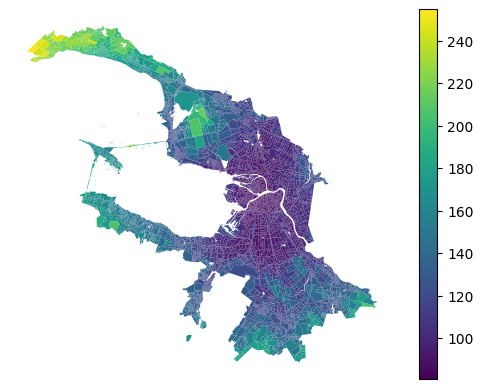

In [20]:
blocks.plot(column='area_accessibility', legend=True).set_axis_off()

In [21]:
# 1. Выведем все dtypes
print(blocks.dtypes)

# 2. Отберём «чисто» категориальные (object / category)
cat_cols = blocks.select_dtypes(include=['object','category']).columns.tolist()
print("Категориальные по dtype:", cat_cols)

# 3. Часто к категориальным относят и числовые колонки с малым числом уникальных значений.
#    Например, если уникальных значений меньше 10:
low_cardinality = [
    col for col in blocks.select_dtypes(include=['int64','float64']).columns
    if blocks[col].nunique() < 10
]
print("Возможно категориальные по низкой кардинальности:", low_cardinality)


geometry              geometry
residential            float64
business               float64
recreation             float64
industrial             float64
transport              float64
special                float64
agriculture            float64
land_use                object
share                  float64
footprint_area         float64
build_floor_area       float64
living_area            float64
non_living_area        float64
population             float64
land_value             float64
site_area              float64
fsi                    float64
gsi                    float64
mxi                    float64
l                      float64
osr                    float64
share_living           float64
share_non_living       float64
morphotype              object
area_accessibility     float64
dtype: object
Категориальные по dtype: ['land_use', 'morphotype']
Возможно категориальные по низкой кардинальности: []


In [22]:
# Очистка базовых невалидных значений
blocks = blocks.replace([np.inf, -np.inf], np.nan).copy()

# Ключевые поля в число
for col in ["land_value", "site_area"]:
    blocks[col] = pd.to_numeric(blocks[col], errors="coerce")

# Удаляем все кварталы, где land_value <= 0 или NaN
blocks = blocks[blocks["land_value"] > 1].copy()

# (Рекомендовано) также убрать нулевую/битую площадь, чтобы деление было корректным
blocks = blocks[blocks["site_area"] > 1].copy()

# Расчёт цены за м² и логов
blocks["land_value_per_sqm"] = blocks["land_value"] / blocks["site_area"]
blocks["log_land_value"] = np.log1p(blocks["land_value"])
blocks["log_land_value_per_sqm"] = np.log1p(blocks["land_value_per_sqm"])

# Быстрая статистика
print(blocks['land_value'].describe())


count    8.728000e+03
mean     5.013825e+08
std      1.026024e+09
min      8.695103e+01
25%      5.457330e+07
50%      1.586168e+08
75%      4.898793e+08
max      2.353281e+10
Name: land_value, dtype: float64


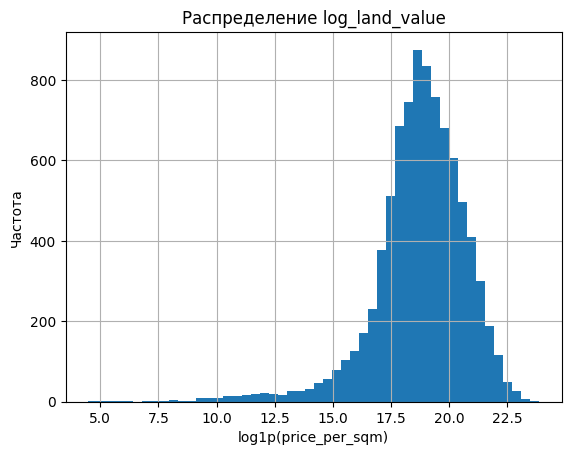

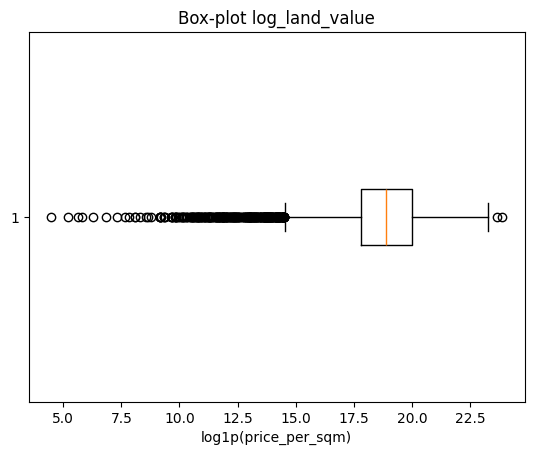

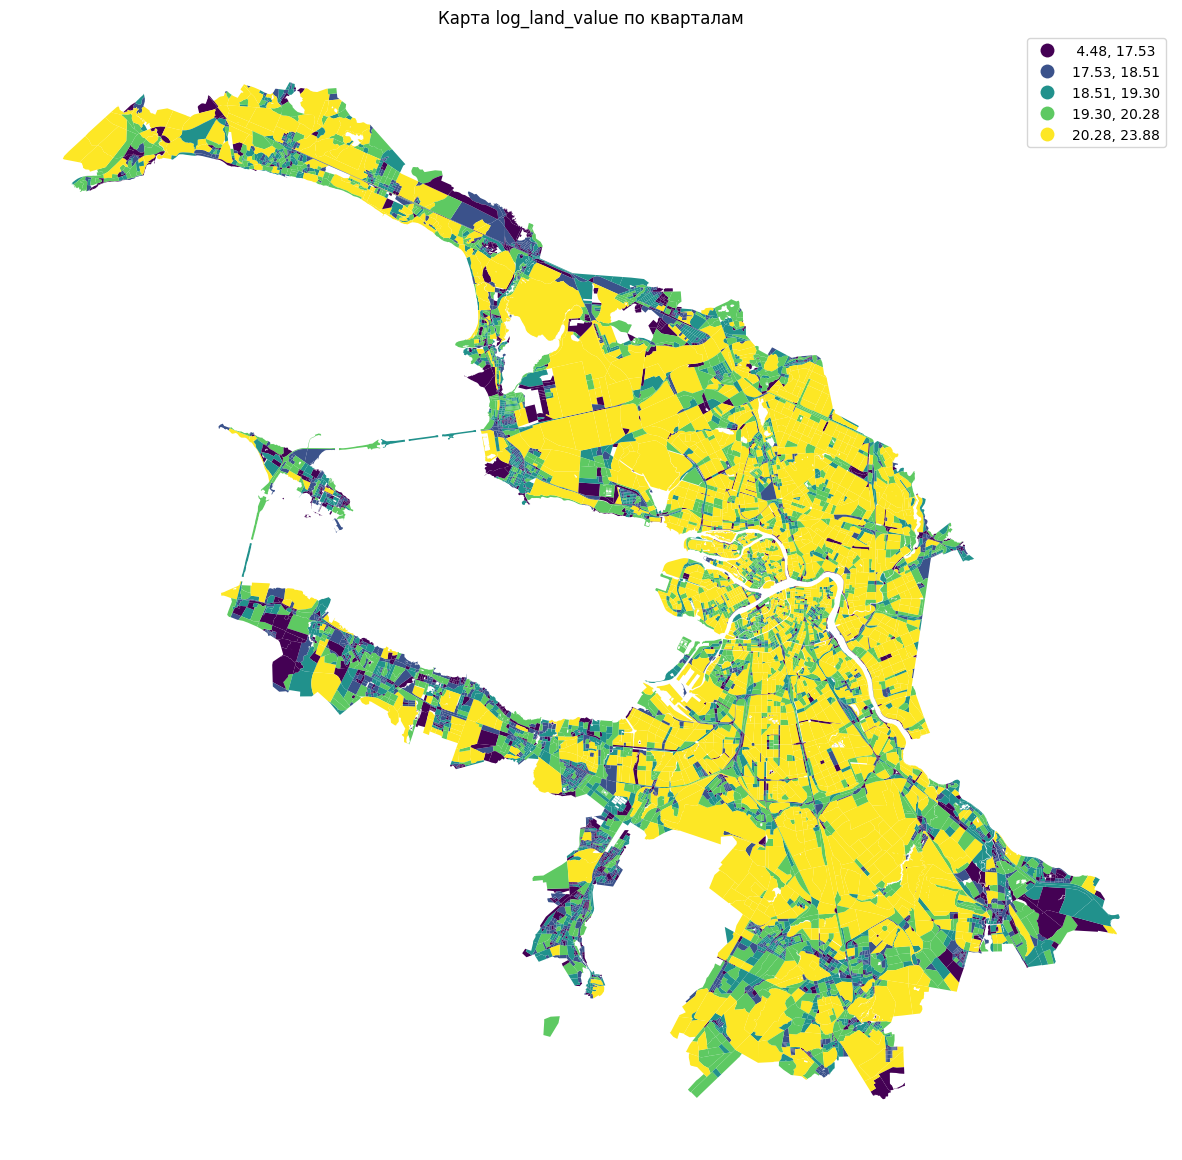

In [23]:

# Гистограмма
plt.figure()
blocks['log_land_value'].hist(bins=50)
plt.xlabel('log1p(price_per_sqm)')
plt.ylabel('Частота')
plt.title('Распределение log_land_value')
plt.show()

# Box-plot
plt.figure()
plt.boxplot(blocks['log_land_value'].dropna(), vert=False)
plt.xlabel('log1p(price_per_sqm)')
plt.title('Box-plot log_land_value')
plt.show()

# Картируем лог-цену
blocks.plot(
    column='log_land_value',
    scheme='quantiles',
    legend=True,
    figsize=(15,15),
    cmap='viridis'
).set_axis_off()
plt.title('Карта log_land_value по кварталам')

plt.show()

In [24]:
import pandas as pd

# 1. Отбираем числовые столбцы и фильтруем
num = blocks.select_dtypes(include=['number'])
num = num[num['land_value'] > 1]

# 2. Считаем count + статистики
agg_stats = num.agg(['count', 'min', 'max', 'mean', 'median', 'std']).T

# 3. Переименовываем столбцы
agg_stats.index.name = 'Variable'
agg_stats = agg_stats.rename(columns={
    'count':  'Count',
    'min':    'Min',
    'max':    'Max',
    'mean':   'Mean',
    'median': 'Median',
    'std':    'SD'
})

# 4. Приводим Count к int
agg_stats['Count'] = agg_stats['Count'].astype(int)

# 5. Округляем остальные метрики
for col in ['Min','Max','Mean','Median','SD']:
    agg_stats[col] = agg_stats[col].round(2)

# 6. Настраиваем глобальный формат для float
pd.options.display.float_format = '{:,.2f}'.format

# 7. Показываем результат
agg_stats


,Count,Min,Max,Mean,Median,SD
Variable,,,,,,
residential,8728,0.00,1.00,0.51,0.68,0.43
business,8728,0.00,1.00,0.03,0.00,0.15
recreation,8728,0.00,1.00,0.19,0.00,0.33
industrial,8728,0.00,1.00,0.05,0.00,0.19
transport,8728,0.00,1.00,0.18,0.07,0.28
special,8728,0.00,1.00,0.01,0.00,0.10
agriculture,8728,0.00,1.00,0.01,0.00,0.11
share,8717,0.00,1.00,0.85,0.91,0.16
footprint_area,8728,0.00,"818,787.73","11,933.56","3,192.12","25,246.22"


In [25]:
# 1) есть ли реально ровно нули
print((blocks["land_value_per_sqm"] == 0).sum())

# 2) какие самые маленькие значения на самом деле
print(blocks["land_value_per_sqm"].nsmallest(10))

# 3) сколько значений "почти ноль"
eps = 1e-6
print((blocks["land_value_per_sqm"] <= eps).sum())



0
2832   0.00
8203   0.00
6003   0.01
5515   0.01
3576   0.01
534    0.02
8254   0.03
8210   0.04
1644   0.05
8576   0.08
Name: land_value_per_sqm, dtype: float64
0


In [26]:
cols_to_drop = [col for col in blocks.columns if col.startswith('capacity')]
cols_to_drop = [col for col in blocks.columns if col.startswith('count')]
# blocks = blocks.drop(columns='cluster')
blocks = blocks.drop(columns=cols_to_drop)

blocks.columns

Index(['geometry', 'residential', 'business', 'recreation', 'industrial',
       'transport', 'special', 'agriculture', 'land_use', 'share',
       'footprint_area', 'build_floor_area', 'living_area', 'non_living_area',
       'population', 'land_value', 'site_area', 'fsi', 'gsi', 'mxi', 'l',
       'osr', 'share_living', 'share_non_living', 'morphotype',
       'area_accessibility', 'land_value_per_sqm', 'log_land_value',
       'log_land_value_per_sqm'],
      dtype='object')

In [ ]:
# blocks.to_parquet('../data/traning_data/prepared_blocks_spb.parquet')

/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_8359/3918900748.py:8: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w1 = libpysal.weights.Queen.from_dataframe(blocks_default)
/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 224 disconnected components.
 There are 193 islands with ids: 145, 365, 366, 495, 929, 1244, 1405, 1420, 1440, 1894, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 2566, 2597, 3272, 3273, 3274, 3275, 3276, 3277, 3278, 3292, 3293, 3294, 3295, 3296, 3297, 3298, 3322, 3323, 3324, 3325, 3326, 3327, 3328, 3329, 3330, 3331, 3332, 3340, 3341, 3342, 3358, 3359, 3360, 3361, 3362, 3363, 3364, 3365, 3366, 3367, 3368, 3406, 3407, 3408, 3409, 3410, 3411, 3417, 3439, 3504, 3763, 3774, 3775, 3883, 3891, 3893, 4027, 4

('WARNING: ', 145, ' is an island (no neighbors)')
('WARNING: ', 365, ' is an island (no neighbors)')
('WARNING: ', 366, ' is an island (no neighbors)')
('WARNING: ', 495, ' is an island (no neighbors)')
('WARNING: ', 929, ' is an island (no neighbors)')
('WARNING: ', 1244, ' is an island (no neighbors)')
('WARNING: ', 1405, ' is an island (no neighbors)')
('WARNING: ', 1420, ' is an island (no neighbors)')
('WARNING: ', 1440, ' is an island (no neighbors)')
('WARNING: ', 1894, ' is an island (no neighbors)')
('WARNING: ', 1934, ' is an island (no neighbors)')
('WARNING: ', 1935, ' is an island (no neighbors)')
('WARNING: ', 1936, ' is an island (no neighbors)')
('WARNING: ', 1937, ' is an island (no neighbors)')
('WARNING: ', 1938, ' is an island (no neighbors)')
('WARNING: ', 1939, ' is an island (no neighbors)')
('WARNING: ', 1940, ' is an island (no neighbors)')
('WARNING: ', 1941, ' is an island (no neighbors)')
('WARNING: ', 1942, ' is an island (no neighbors)')
('WARNING: ', 194

/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/esda/moran.py:1350: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


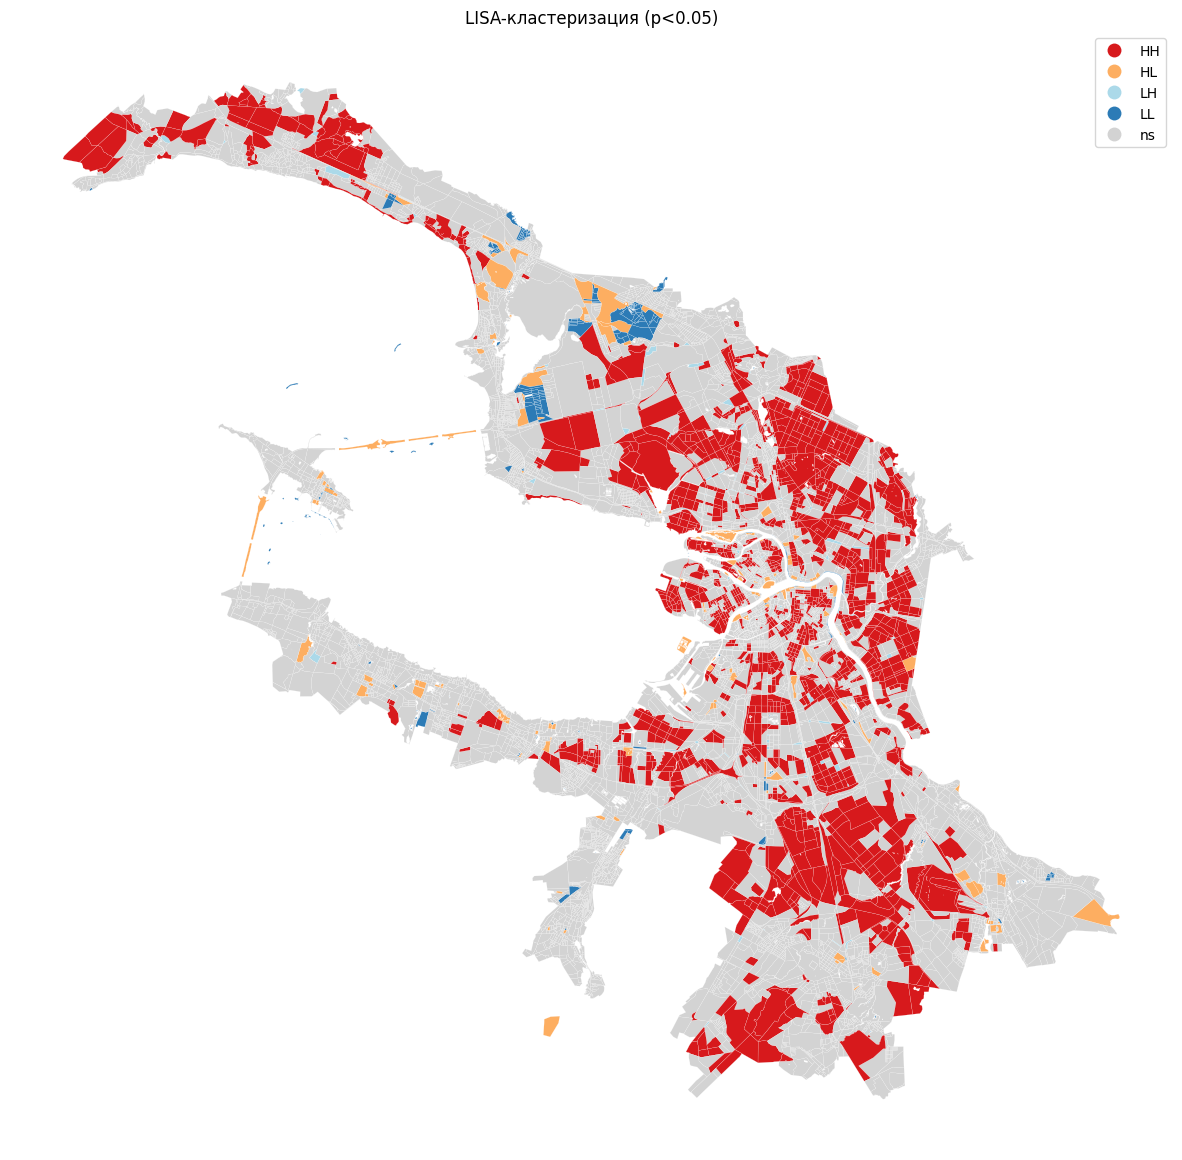

In [34]:
import libpysal
from esda.moran import Moran, Moran_Local
import matplotlib.pyplot as plt
from splot.esda import lisa_cluster

# 1) Подготовка: spatial weights
# Если у вас уже есть w1 (Rook или Queen), используем его, иначе:
w1 = libpysal.weights.Queen.from_dataframe(blocks_default)
# или: w1 = libpysal.weights.Rook.from_dataframe(blocks)
w1.transform = 'r'   # row-standardization

# 2) Извлекаем вектор переменной
y = blocks_default['log_total_price'].values

# 3) Глобальный индекс Морена
moran_global = Moran(y, w1)
print("Global Moran’s I:",     round(moran_global.I,3))
print("p-value (normal):",     round(moran_global.p_norm,3))
print("z-score (normal):",     round(moran_global.z_norm,3))
print("p-value (permut.):",    round(moran_global.p_sim,3))
print("z-score (permut.):",    round(moran_global.z_sim,3))

# 4) Локальный индекс Морена
lisa = Moran_Local(y, w1)

# 5) Добавляем результаты в GeoDataFrame
blocks_default['lisa_I']   = lisa.Is          # локальные значения I
blocks_default['lisa_p']   = lisa.p_sim       # p-values по перестановкам
blocks_default['lisa_q']   = lisa.q           # квадранты (1=HH, 2=LH, 3=LL, 4=HL)
blocks_default['lisa_sig'] = lisa.p_sim < 0.05

# 6) Визуализация LISA-кластеров
fig, ax = plt.subplots(1, figsize=(15, 15))
# splot умеет сам раскрасить по четырём кластерам
lisa_cluster(lisa, blocks_default, p=0.05, ax=ax)
ax.set_title("LISA-кластеризация (p<0.05)")
ax.axis('off')
plt.show()


In [35]:
blocks_default

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,l,osr,share_living,share_non_living,morphotype,area_accessibility,lisa_I,lisa_p,lisa_q,lisa_sig
0,"POLYGON ((349424.859 6631180.891, 349424.751 6...",0.00,0.00,0.00,0.00,1.00,0.00,0.00,TRANSPORT,1.00,...,0.00,inf,NaN,NaN,NaN,114.18,-0.90,0.39,2,False
1,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.10,0.00,0.08,0.00,0.40,0.00,0.42,AGRICULTURE,0.42,...,1.00,"1,985.45",0.00,1.00,low-rise non-residential,113.85,0.06,0.43,1,False
2,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.00,0.00,0.00,0.00,0.00,0.00,0.00,RESIDENTIAL,1.00,...,1.04,14.64,0.72,0.33,individual residential,145.88,-0.07,0.22,4,False
3,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.73,0.00,0.27,0.00,0.00,0.00,0.00,RESIDENTIAL,0.73,...,1.04,27.82,0.72,0.32,individual residential,148.54,0.10,0.20,1,False
4,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.45,0.00,0.00,0.00,0.14,0.00,0.40,RESIDENTIAL,0.45,...,2.33,5.01,1.56,0.78,low-rise model,132.69,0.13,0.23,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9363,"POLYGON ((346635.461 6647492.048, 346473.426 6...",0.94,0.00,0.00,0.00,0.06,0.00,0.00,RESIDENTIAL,0.94,...,4.94,0.58,2.27,2.67,mid-rise,92.74,0.18,0.01,1,True
9364,"POLYGON ((346361.221 6647603.446, 346328.072 6...",0.13,0.00,0.27,0.00,0.61,0.00,0.00,TRANSPORT,0.61,...,4.89,0.45,0.00,4.89,mid-rise non-residential,94.56,0.29,0.00,1,True
9365,"POLYGON ((344109.285 6649134.367, 344000.209 6...",0.00,0.00,0.76,0.00,0.23,0.00,0.00,RECREATION,0.76,...,1.00,"2,510.80",0.00,1.00,low-rise non-residential,100.50,0.15,0.06,1,False
9366,"POLYGON ((346323.488 6649497.386, 346199.573 6...",0.40,0.00,0.00,0.47,0.12,0.00,0.00,INDUSTRIAL,0.47,...,4.06,0.57,0.00,4.06,mid-rise non-residential,92.49,-0.02,0.38,4,False
